# Section 2 &middot; How Backtests Lie

*The Honest Edge.*

Section 1 ended on a loaded question: shuffling the data changed our score for
free. On a no-signal problem it barely mattered. This section makes good on the
threat. We will build a question that **does** contain a pattern, show that the
same innocent-looking shuffle now manufactures a **fake edge** worth ~5
percentage points of accuracy, and then take it apart with honest validation.

Then the real test: we trade the honest version, pay realistic costs, and line it
up against **buy-and-hold SPY**, the baseline this whole course exists to beat.
The result is the quiet truth most backtests hide.

## Step 1: a target with overlap

Predicting *tomorrow* had no signal. So let's ask an easier question: **will SPY
be higher 10 trading days from now?** Over a longer horizon the upward drift has
room to show through, so there is finally something to predict.

But that horizon plants a trap. Today's label asks about the next 10 days.
Tomorrow's label asks about *its* next 10 days. Those two windows **share 9 of
their 10 days**, so the two rows have nearly the same answer, and nearly the same
features. **Adjacent rows are near-duplicates.**

**Analogy: a paraphrased exam question.** If your practice set secretly contains a
reworded copy of a question on the real exam, you will ace it and learn nothing.
Overlapping labels scatter paraphrased copies everywhere. Whether that helps or
hurts depends entirely on which side of the train/test line they land, which is
the whole game.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from honest_edge import data, indicators as ind, evaluation as ev

spy = data.load_spy_daily()
close = spy["close"]

# Same simple features as Section 1, plus one deliberately SLOW feature
# (distance from the 50-day average). Slow features barely move day to day, which
# makes neighboring rows look even more alike, sharpening the leakage we want to expose.
# RSI comes from the library (the one definition of every indicator, as in Section 1).
feat = pd.DataFrame(index=spy.index)
feat["ret_1"] = close.pct_change(1)
feat["ret_2"] = close.pct_change(2)
feat["mom_10"] = close.pct_change(10)
feat["ma_dist"] = close / close.rolling(20).mean() - 1.0
feat["rsi_14"] = ind.rsi(close, 14)
feat["px_vs_sma50"] = close / close.rolling(50).mean() - 1.0

HORIZON = 10
fwd_return = close.shift(-HORIZON) / close - 1.0           # return over the NEXT 10 days (the future)
label = (fwd_return > 0).astype(float).where(fwd_return.notna())

dataset = feat.copy()
dataset["y"] = label
dataset = dataset.dropna()
X = dataset.drop(columns="y")
y = dataset["y"].astype(int)
print(f"rows: {len(dataset)}   up-rate over 10 days: {y.mean():.1%}")

rows: 4941   up-rate over 10 days: 62.8%


## Step 2: two ways to split, one honest, one not

We will score the **same model** (a depth-8 decision tree, exactly the kind of
flexible learner that memorized noise in Section 1) two ways:

- **Shuffled K-fold** , scramble all the days, then split. Ignores time. This is
  the cheat.
- **Purged walk-forward** , train on the past, test on the future, with safeguards
  we will explain in a moment. This is honest.

A quick helper trains a fresh tree on each fold and returns the test accuracies.

In [2]:
def cv_accuracies(folds):
    scores = []
    for train_idx, test_idx in folds:
        model = DecisionTreeClassifier(max_depth=8, random_state=0)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        scores.append(accuracy_score(y.iloc[test_idx], model.predict(X.iloc[test_idx])))
    return np.array(scores)

shuffled = cv_accuracies(ev.shuffled_kfold(len(X), n_splits=5, seed=0))
print(f"SHUFFLED (cheating) mean accuracy: {shuffled.mean():.2%}")
print("per fold:", np.round(shuffled, 3))
print("Notice how tight the folds are. It looks reliable. Hold that thought.")

SHUFFLED (cheating) mean accuracy: 61.61%
per fold: [0.612 0.608 0.622 0.618 0.619]
Notice how tight the folds are. It looks reliable. Hold that thought.


## Step 3: the honest split, purge and embargo

**Walk-forward** is the honest default: train on the past, test on the next block
of time, then roll forward and repeat. **Analogy:** re-sitting an exam every year,
allowed only the textbooks printed *so far*.

Two extra safeguards handle the overlap:

- **Purge** , drop the last few training rows whose 10-day label reaches *into*
  the test window. **Analogy:** tear the last pages out of the study guide because
  their answers quote next week's quiz.
- **Embargo** , skip a small extra buffer right before the test block. Even after
  purging label overlap, the last training days and the first test days share the
  same market mood (calm and panicky days arrive in streaks), so a model that
  learned today's mood gets a small unfair hint about tomorrow's. The embargo
  throws away those borderline days. **Analogy:** a cooling-off gap so yesterday's
  mood does not bleed into the exam.

```
   [============ TRAIN (expanding) ============][purge][embargo][== TEST ==]  ->
   roll forward, repeat
```

The picture below draws one real fold so the gap is concrete.

5 folds, all train-before-test. Purge+embargo gap on fold 1: 109 bars.


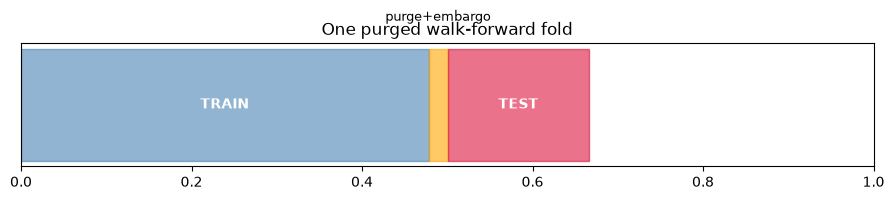

In [3]:
folds = ev.purged_walk_forward(len(X), n_splits=5, embargo_frac=0.02, label_horizon=HORIZON)

# Prove the contract: every fold trains strictly before it tests, with a real gap.
for i, (tr, te) in enumerate(folds, 1):
    assert tr.max() < te.min(), "look-ahead leak!"
gap = folds[0][1].min() - folds[0][0].max()
print(f"{len(folds)} folds, all train-before-test. Purge+embargo gap on fold 1: {gap} bars.")

# Draw fold 3's timeline.
tr, te = folds[2]
fig, ax = plt.subplots(figsize=(11, 1.6))
ax.axhspan(0, 1, xmin=tr.min() / len(X), xmax=tr.max() / len(X), color="steelblue", alpha=0.6)
ax.axhspan(0, 1, xmin=tr.max() / len(X), xmax=te.min() / len(X), color="orange", alpha=0.6)
ax.axhspan(0, 1, xmin=te.min() / len(X), xmax=te.max() / len(X), color="crimson", alpha=0.6)
ax.text(tr.max() / 2 / len(X), 0.5, "TRAIN", ha="center", va="center", color="white", weight="bold")
ax.text((tr.max() + te.min()) / 2 / len(X), 1.25, "purge+embargo", ha="center", fontsize=9)
ax.text((te.min() + te.max()) / 2 / len(X), 0.5, "TEST", ha="center", va="center", color="white", weight="bold")
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_title("One purged walk-forward fold")
plt.show()

In [4]:
purged = cv_accuracies(folds)
inflation = shuffled.mean() - purged.mean()
print(f"SHUFFLED (cheating) mean: {shuffled.mean():.2%}")
print(f"PURGED   (honest)   mean: {purged.mean():.2%}")
print(f"per honest fold: {np.round(purged, 3)}  <- jumpy, the real world is noisy")
print(f"\nINFLATION from cheating: +{inflation:.2%} of accuracy, conjured from nothing.")

SHUFFLED (cheating) mean: 61.61%
PURGED   (honest)   mean: 56.52%
per honest fold: [0.483 0.573 0.583 0.552 0.635]  <- jumpy, the real world is noisy

INFLATION from cheating: +5.08% of accuracy, conjured from nothing.


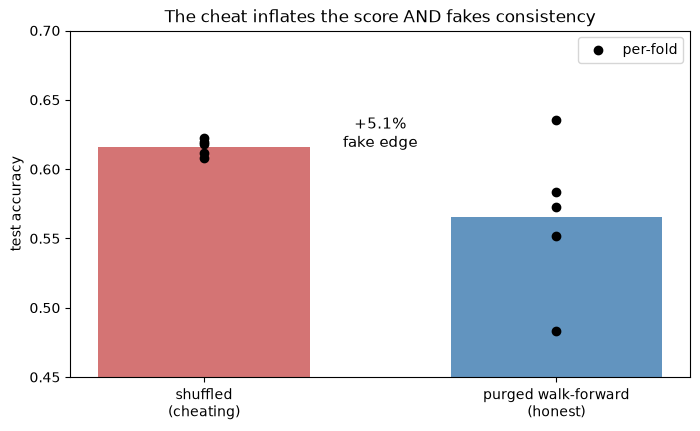

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
means = [shuffled.mean(), purged.mean()]
ax.bar(["shuffled\n(cheating)", "purged walk-forward\n(honest)"], means,
       color=["indianred", "steelblue"], alpha=0.85, width=0.6)
ax.scatter([0] * len(shuffled), shuffled, color="black", zorder=3, label="per-fold")
ax.scatter([1] * len(purged), purged, color="black", zorder=3)
ax.annotate(f"+{inflation:.1%}\nfake edge", xy=(0.5, max(means)), ha="center", fontsize=11)
ax.set_ylabel("test accuracy"); ax.set_ylim(0.45, 0.70)
ax.set_title("The cheat inflates the score AND fakes consistency")
ax.legend()
plt.show()

Same model, same data, same features. The **only** difference is whether the test
days' near-duplicate neighbors were allowed into training. Cheating did two
things: it lifted the average, and, more insidiously, the shuffled folds were all
bunched together, so the cheat *looked* trustworthy and stable. Honest validation
is lower **and** noisier, because honesty includes admitting how uncertain you are.

In [6]:
# Sanity check the claim "leakage bites hardest where there's signal": redo it on
# the next-bar target from Section 1 (horizon 1, almost no signal, little overlap).
fwd1 = close.shift(-1) / close - 1.0
y1 = (fwd1 > 0).astype(float).where(fwd1.notna())
d1 = feat.copy(); d1["y"] = y1; d1 = d1.dropna()
X1, y1 = d1.drop(columns="y"), d1["y"].astype(int)

def cv_acc_on(Xd, yd, folds):
    out = []
    for tr, te in folds:
        m = DecisionTreeClassifier(max_depth=8, random_state=0).fit(Xd.iloc[tr], yd.iloc[tr])
        out.append(accuracy_score(yd.iloc[te], m.predict(Xd.iloc[te])))
    return np.mean(out)

sh1 = cv_acc_on(X1, y1, ev.shuffled_kfold(len(X1), 5, 0))
pw1 = cv_acc_on(X1, y1, ev.purged_walk_forward(len(X1), 5, 0.02, 1))
print(f"horizon 1  shuffled {sh1:.2%} vs purged {pw1:.2%}  ->  inflation {sh1 - pw1:+.2%} (~zero)")
print(f"horizon 10 shuffled {shuffled.mean():.2%} vs purged {purged.mean():.2%}  ->  inflation {inflation:+.2%} (large)")
print("\nAt horizon 1 there is no signal and little overlap, so the cheat buys")
print("nothing: the gap is pure noise around zero (here it even lands slightly")
print("negative). Leakage needs signal/overlap to feed on. The more there is to")
print("find, the more cheating flatters you, exactly when you most want to trust it.")

horizon 1  shuffled 53.21% vs purged 54.08%  ->  inflation -0.87% (~zero)
horizon 10 shuffled 61.61% vs purged 56.52%  ->  inflation +5.08% (large)

At horizon 1 there is no signal and little overlap, so the cheat buys
nothing: the gap is pure noise around zero (here it even lands slightly
negative). Leakage needs signal/overlap to feed on. The more there is to
find, the more cheating flatters you, exactly when you most want to trust it.


## Step 4: is the honest 56% even worth trading?

A higher-than-coin-flip accuracy still proves nothing. Accuracy is not money. The
only honest test is to **trade the signal and pay to play.** Two rules, both from
Section 0:

- **One-bar execution lag.** The position chosen at today's close is held over the
  next bar's return (`positions.shift(1)` inside the backtest): we assume a
  market-on-close order, so we never trade on information we could not have had.
- **Costs on every trade.** SPY's bid-ask spread is about a penny (~1-2 bps), and
  we pay it each time we change position. We will charge a conservative 2 bps and
  then test how sensitive the result is to that number.

**A simplification, stated plainly:** the model predicts a *10-day-ahead*
direction, but we trade it as a plain one-bar long/flat position that refreshes
each day (long whenever today's prediction is "up"). That keeps the harness
identical to every other section and does **not** leak (the predictions are still
purged and embargoed), but it does mean the bet placed is "be long for one bar,"
not "be long for ten." We trade the simple version on purpose; the conclusion
below does not hinge on the horizon.

In [7]:
# Honest out-of-sample predictions: each fold predicts only its own unseen test block.
oos_pred = pd.Series(index=dataset.index, dtype=float)
for train_idx, test_idx in folds:
    model = DecisionTreeClassifier(max_depth=8, random_state=0).fit(X.iloc[train_idx], y.iloc[train_idx])
    oos_pred.iloc[test_idx] = model.predict(X.iloc[test_idx])
oos_pred = oos_pred.dropna()

positions = (oos_pred > 0).astype(float)         # long when the model says up, else flat
prices = close.reindex(positions.index)
print(f"out-of-sample span: {positions.index.min().date()} -> {positions.index.max().date()}")
print(f"in the market {positions.mean():.0%} of the time, {int(positions.diff().abs().sum())} trades")

out-of-sample span: 2009-10-22 -> 2026-03-06
in the market 72% of the time, 997 trades


## Step 5: the metrics, and the baselines that matter

A return stream is judged on more than its total. We use:

- **Sharpe** , return per unit of total wobble (annualized with sqrt(252) for daily data).
- **Sortino** , like Sharpe but only penalizes *downside* wobble.
- **Max drawdown** , the worst peak-to-trough fall. **Calmar** , return divided by that pain.

And we compare against the only baselines that count:

- **Buy-and-hold SPY** , the headline. Beat this after costs or you have nothing.
- **A random long/flat trader** , a monkey flipping coins, same machinery, no skill.

**Pitfall:** total return alone is not risk-adjusted. A strategy can "win" on
total return by taking more risk, or lose on total return while having a steadier
ride. Always read them together.

In [8]:
# ev.summary_row projects perf_metrics down to the four headline numbers; it lives
# in the library so Sections 2 and 3 render metrics identically.
strat = ev.backtest_positions(positions, prices, cost_bps=2.0)
bh = ev.buy_and_hold(prices)
rnd = ev.backtest_positions(ev.random_positions(positions.index, seed=0), prices, cost_bps=2.0)

table = pd.DataFrame({"Strategy (2 bps)": ev.summary_row(strat),
                      "Buy & Hold SPY": ev.summary_row(bh),
                      "Random (2 bps)": ev.summary_row(rnd)}).T
table.style.format({"Sharpe": "{:.2f}", "Sortino": "{:.2f}",
                    "max DD": "{:.1%}", "total return": "{:.0%}"})

,Sharpe,Sortino,max DD,total return
Strategy (2 bps),0.67,0.94,-34.1%,327%
Buy & Hold SPY,0.73,1.03,-34.1%,515%
Random (2 bps),0.38,0.52,-26.8%,89%


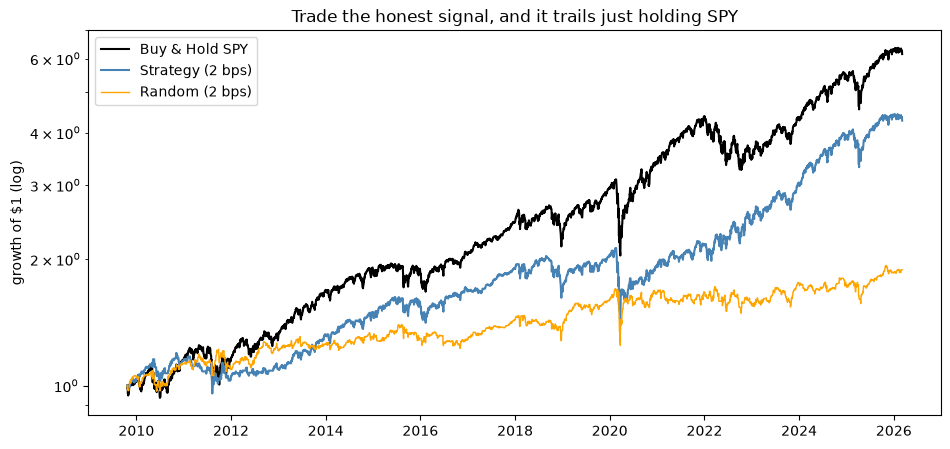

In [9]:
eq = ev.equity_curve   # growth of $1, from the library

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq(bh).index, eq(bh), color="black", lw=1.5, label="Buy & Hold SPY")
ax.plot(eq(strat).index, eq(strat), color="steelblue", lw=1.5, label="Strategy (2 bps)")
ax.plot(eq(rnd).index, eq(rnd), color="orange", lw=1, label="Random (2 bps)")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)")
ax.set_title("Trade the honest signal, and it trails just holding SPY")
ax.legend()
plt.show()

In [10]:
# How much do costs matter? Re-run everything at 0, 2, and 5 bps.
rows = {}
for bps in [0, 2, 5]:
    s = ev.perf_metrics(ev.backtest_positions(positions, prices, cost_bps=bps))
    r = ev.perf_metrics(ev.backtest_positions(ev.random_positions(positions.index, 0), prices, cost_bps=bps))
    rows[f"{bps} bps"] = {"Strategy Sharpe": s["sharpe"], "Strategy total": s["total_return"],
                          "Random Sharpe": r["sharpe"], "Random total": r["total_return"]}
cost_table = pd.DataFrame(rows).T
cost_table.style.format({"Strategy Sharpe": "{:.2f}", "Strategy total": "{:.0%}",
                         "Random Sharpe": "{:.2f}", "Random total": "{:.0%}"})

,Strategy Sharpe,Strategy total,Random Sharpe,Random total
0 bps,0.75,421%,0.58,184%
2 bps,0.67,327%,0.38,89%
5 bps,0.55,217%,0.07,2%


## The honest verdict

Read the tables and the curve together:

- The cheating split bragged ~62% accuracy. The honest split was ~56%. And that
  honest 56%, **once you actually trade it and pay costs, loses to buy-and-hold
  SPY.** Even with zero costs the "edge" is a rounding error on Sharpe, bought by
  giving up a large chunk of total return. The model just learned to be long most
  of the time, so it is, at best, **a worse buy-and-hold.**
- The **random trader is what costs destroy**: fine at 0 bps, bleeding at 5. High
  turnover plus friction is its own way to lose.

This is the whole reason the honest harness exists. Without it, the 62% number
would have walked straight into a slide deck.

**Pitfalls met in this section:**
1. Shuffled cross-validation on time-ordered data.
2. Overlapping-label leakage (near-duplicate neighbors).
3. Ignoring trading costs.
4. Cherry-picking the metric (total return vs Sharpe vs drawdown).
5. Too-few folds / one number is one die roll.
6. Comparing strategies with different trade counts.

(The professional next level, combinatorial purged cross-validation and the
Deflated Sharpe, we save for Section 9, once we have edges worth deflating.)

## What's next

We now have a harness we can trust. So far every "signal" has been a generic ML
guess. **Section 3** brings a real, named, decades-old strategy, **Connors
RSI(2)**, the famous "buy SPY when it is oversold" rule, and runs it through this
exact honest gauntlet. Does a strategy people actually trade survive? That is
where the course earns its title.